In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('dataset.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LetterOfRecommendation,CGPA,Research,Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [3]:
df = df.loc[:, 'GRE Score':]

In [4]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LetterOfRecommendation,CGPA,Research,Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0.82
396,325,107,3,3.0,3.5,9.11,1,0.84
397,330,116,4,5.0,4.5,9.45,1,0.91
398,312,103,3,3.5,4.0,8.78,0,0.67


In [5]:
df1 = df.rename({'GRE Score': 'GRE_SCORE', 'TOEFL Score': 'TOEFL_SCORE', 'University Rating': 'UNIVERSITY_RATING'}, axis=1)
df1.head()

,GRE_SCORE,TOEFL_SCORE,UNIVERSITY_RATING,SOP,LetterOfRecommendation,CGPA,Research,Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df1.isnull().sum()

GRE_SCORE                 0
TOEFL_SCORE               0
UNIVERSITY_RATING         0
SOP                       0
LetterOfRecommendation    0
CGPA                      0
Research                  0
Admit                     0
dtype: int64

In [7]:
df1.describe()

,GRE_SCORE,TOEFL_SCORE,UNIVERSITY_RATING,SOP,LetterOfRecommendation,CGPA,Research,Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


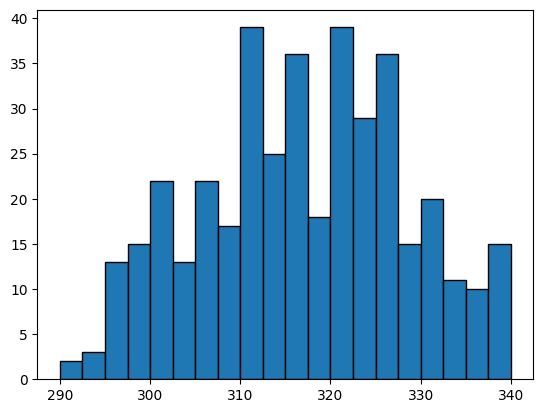

In [8]:
plt.hist(df1['GRE_SCORE'], edgecolor='black', bins=20)
plt.show()

In [9]:
Y = df1['Admit']
X = df1.drop(['Admit'], axis=1)
X.head()

,GRE_SCORE,TOEFL_SCORE,UNIVERSITY_RATING,SOP,LetterOfRecommendation,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)

In [11]:
X_train.shape, y_train.shape

((280, 7), (280,))

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train, y_train)

LinearRegression()

In [15]:
lr.score(X_train, y_train)

0.8147518126375592

In [16]:
lr.score(X_test, y_test)

0.7687460045166157

In [17]:
predicted = lr.predict(X_test)

In [18]:
from sklearn.metrics import root_mean_squared_error, r2_score 

In [19]:
print(f'RMSE : {root_mean_squared_error(y_test, predicted)}')
print(f'R2 : {r2_score(y_test, predicted)}')

RMSE : 0.06516880544654977
R2 : 0.7687460045166157


In [20]:
X.columns

Index(['GRE_SCORE', 'TOEFL_SCORE', 'UNIVERSITY_RATING', 'SOP',
       'LetterOfRecommendation', 'CGPA', 'Research'],
      dtype='object')

In [ ]:
import streamlit as st
st.title('Shortlisting Universities with Based on your profiles')

st.sidebar.header('USER INPUT')

def user_input():

    gre = st.sidebar.number_input('GRE_SCORE')
    toefl = st.sidebar.number_input('TOEFL_SCORE')
    u_rating = st.sidebar.number_input('UNIVERSITY_RATING')
    sop = st.sidebar.number_input('SOP')
    lor = st.sidebar.number_input('LetterOfRecommendation')
    cgpa = st.sidebar.number_input('CGPA')
    research = st.sidebar.number_input('Research')

    data = {'GRE': gre,'TOEFL': toefl, 'University_rating': u_rating,'SOP': sop,'LOR': lor,'CGPA': cgpa,'RESEARCH': research}

    features = pd.DataFrame(data)

    return features

input_df = user_input()

st.subheader('USER INPUT PARAMETERS')


In [22]:
import pickle
# Assuming 'model' is your trained machine learning model

filename = 'finalized_model_lr.pkl'

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(lr, file)

print(f"Model saved as {filename}")

Model saved as finalized_model_lr.pkl
